# This file plots the normalized hysteresis area for sea surface salinity

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = False
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr() #Params.test_set_1pctCO2cdr()  #

Setting parameters...


## Choose the variable that is to be analyzed - and its temporal resolution

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'so'
depth_to_analyze = 'surface'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the model data for the variable of choice

In [5]:
print("Opening the variable's model dataset...")
run_paths = ModelDataGetter._identify_path_strings(run_params,variable_to_analyze,depth_to_analyze)
ds_data   = ModelDataGetter._open_datasets(run_paths)

Opening the variable's model dataset...


## Get the additional ocean mask, area weights, atmospheric CO2, and ocean regions

In [7]:
print('Getting miscellaneous data...')
da_omask  = MiscDataGetter._get_ocean_mask()
da_area   = MiscDataGetter._get_grid_cell_areas()
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
ds_oregs, reg_lookup_dict  = MiscDataGetter._get_ocean_regions()

Getting miscellaneous data...
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2


## Compute the hysteresis area for the variable of choice - and compute the multimodel mean and agreements

In [8]:
hyst_dict = HystFuncs._calc_hysteresis_areas_3D_multimodel(run_params,ds_data,temporal_resolution,ds_atmCO2)

Calculating hysteresis area for model UKESM1-0-LL (key 2)...
Calculating hysteresis area for model NorESM2-LM (key 3)...
Calculating hysteresis area for model MIROC-ES2L (key 4)...
Calculating hysteresis area for model CNRM-ESM2-1 (key 5)...
Calculating hysteresis area for model ACCESS-ESM1-5 (key 6)...
Calculating hysteresis area for model CESM2 (key 7)...
Calculating hysteresis area for model CanESM5 (key 8)...
Calculating hysteresis area for model GFDL-ESM4 (key 9)...


In [8]:
print('Calculating multimodel mean and model agreement ...')
h_mmm,  h_agree  = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='hysteresis_area',            agreement_type='mean_bigger_than_std')
hn_mmm, hn_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='normalized_hysteresis_area', agreement_type='mean_bigger_than_std')
hs_mmm, hs_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='signed_hysteresis_area', agreement_type='sign', agreement_thresh='at_least_80percent_agree')

Calculating multimodel mean and model agreement ...


## Pick example locations and regions for local analysis

In [9]:
set_of_loc_reg = MiscDataGetter._standard_set_of_regions_locations()
print('Chosen locations: ', set_of_loc_reg)

Chosen locations:  ['Global Ocean', [88, 260], [60, 90], 'central Arctic']


## Plot the multimodel mean normalized hysteresis area for the variable as a global map

Plot the multimodel mean hysteresis areas - globally....


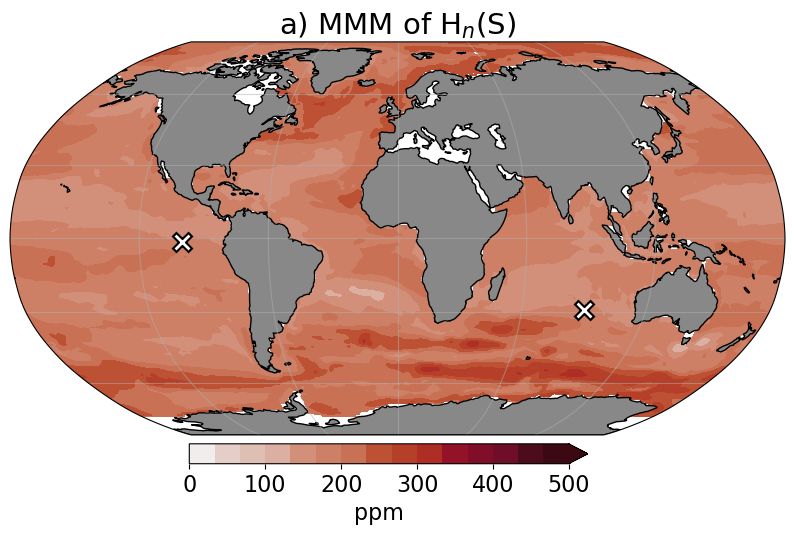

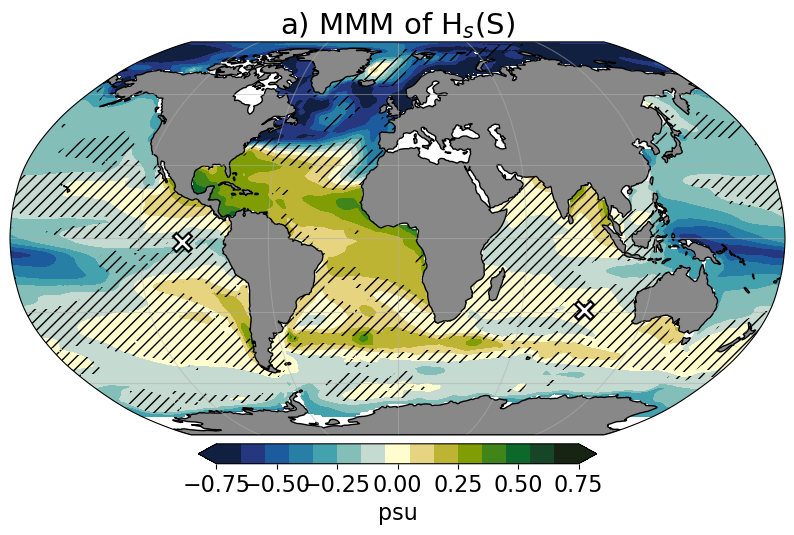

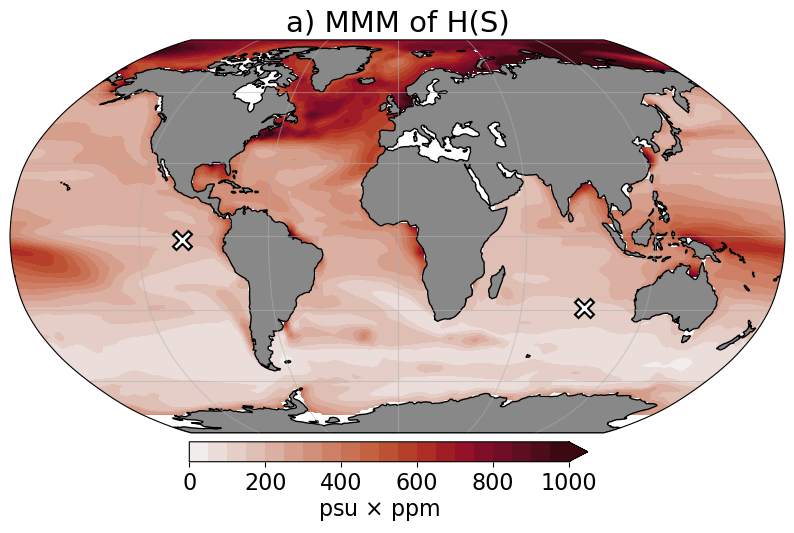

In [11]:
print('Plot the multimodel mean hysteresis areas - globally....')

fig, ax = Plotter.plot_global_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=500,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',20),
                                  cticks = [0,100,200,300,400,500],
                                  extend='max',
                                  clabel='ppm',
                                  title=r'a) MMM of H$_n$(S)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_normalized_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_global_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-.75,
                                  vmax=.75,
                                  nlevs=16,
                                  cticks = [-.75,-.5,-.25,0,.25,.5,.75],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',15),
                                  extend='both',
                                  clabel='psu',
                                  title=r'a) MMM of H$_s$(S)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_signed_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_global_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=1000,
                                  nlevs=21,
                                  cticks = [0,200,400,600,800,1000],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',20),
                                  extend='max',
                                  clabel=r'psu $\times$ ppm',
                                  title=r'a) MMM of H(S)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_full_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)



## Plot the multimodel mean normalized hysteresis area for the variable as an Arctic map

Plot the multimodel mean hysteresis areas - for the Arctic....


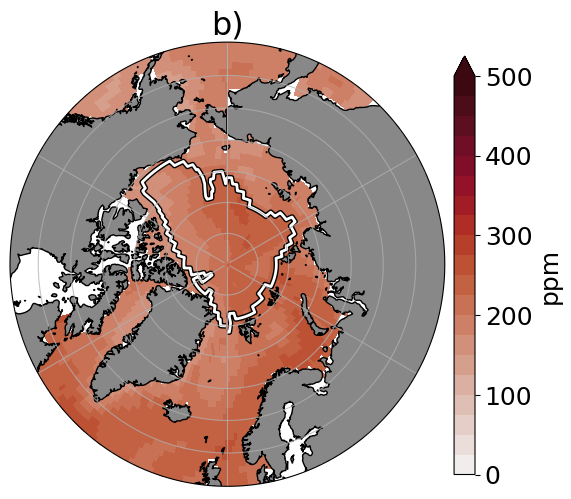

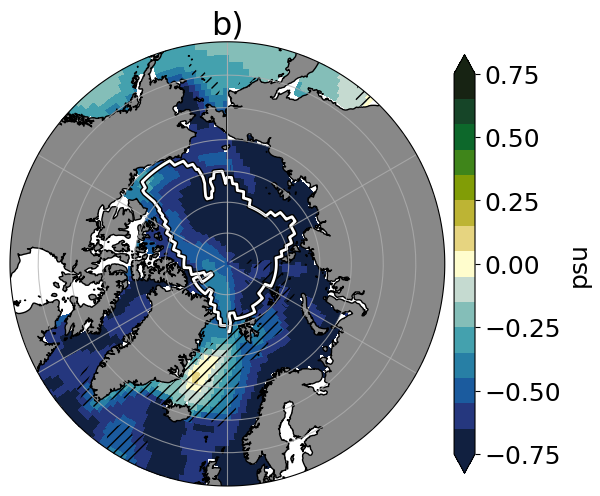

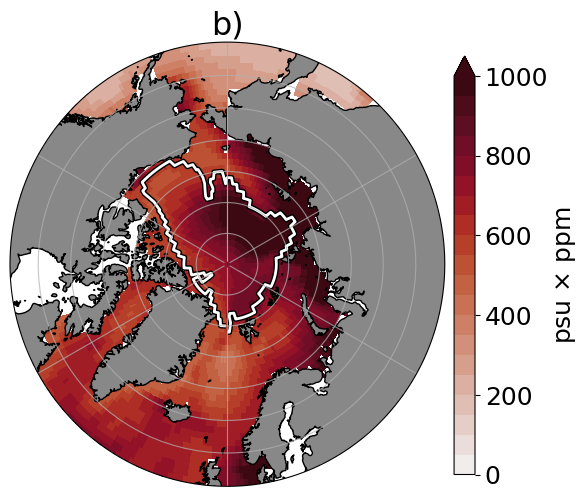

In [12]:
print('Plot the multimodel mean hysteresis areas - for the Arctic....')

fig, ax = Plotter.plot_arctic_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=500,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',20),
                                  cticks = [0,100,200,300,400,500],
                                  extend='max',
                                  clabel='ppm',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_arctic_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-.75,
                                  vmax=.75,
                                  nlevs=16,
                                  cticks = [-.75,-.5,-.25,0,.25,.5,.75],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',15),
                                  extend='both',
                                  clabel='psu',
                                  title=r'b)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_arctic_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=1000,
                                  nlevs=21,
                                  cticks = [0,200,400,600,800,1000],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',20),
                                  extend='max',
                                  clabel=r'psu $\times$ ppm',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_full_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


## Compute regional mean or extract point location time series of the variable of choice

In [13]:
print('Get time series....')
regional_time_series = MMFuncs._calc_regional_means(run_params,set_of_loc_reg,ds_data,temporal_resolution)

Get time series....


## Plot the timeseries (against atmospheric CO2) at the chosen locations

Plot the timeseries against atmospheric CO2 at four different locations....


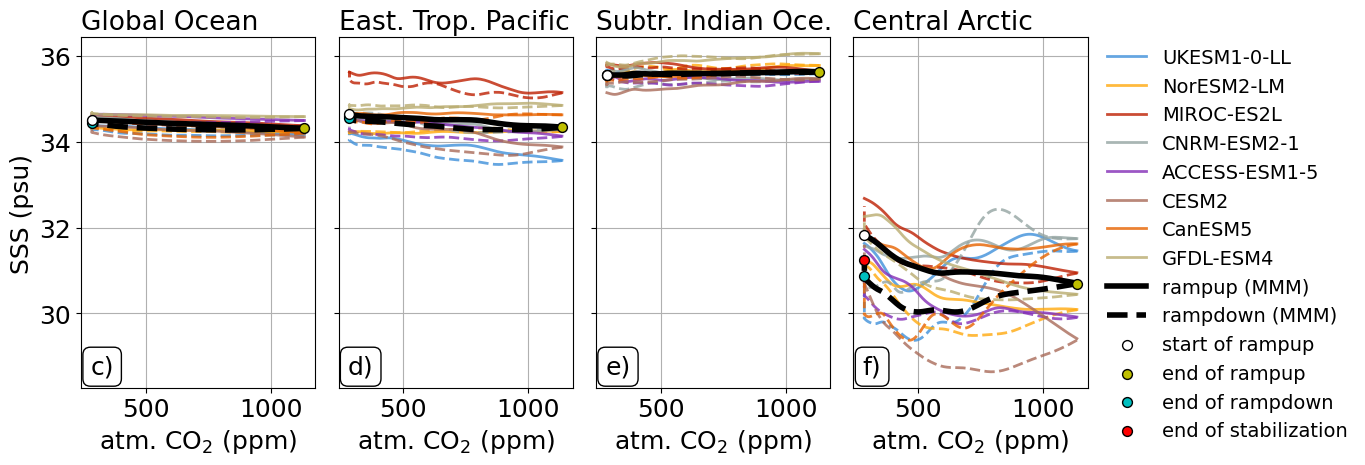

In [14]:
def plot_four_timeseries_against_atmCO2(run_params,regional_time_series,ds_atmCO2,set_of_loc_reg):

    panel_labels = ['c','d','e','f']
    up_index_all = []
    dn_index_all = []
    rampup_val_all = []
    rampdn_val_all = []
    
    start_val_all = []
    end_val_all = []
    diff_val_all = []

    fontsize=18
    fig, ax = plt.subplots(1,len(set_of_loc_reg),figsize=(14,5),sharey=True)

    # loop over regions
    for idx,loc_or_reg in enumerate(set_of_loc_reg):
        # loop over runs
        data_to_plot_all = [] 
        for key in run_params.keys():
            
            # Get the CO2 
            atmCO2 = ds_atmCO2[key]
            rampup_atmCO2   = atmCO2.isel(year=slice(0,  140))
            rampdown_atmCO2 = atmCO2.isel(year=slice(140,340))

            # Get the data
            # First, get the right region string
            if isinstance(loc_or_reg,str):
                loc_or_reg_string = loc_or_reg
            elif isinstance(loc_or_reg,list):
                loc_or_reg_string = f'point_{loc_or_reg[0]}_{loc_or_reg[1]}'
            else:
                raise Exception('Not yet implemented')
            
            # Now get the data and smooth it for better readability
            reg_time_series = regional_time_series[loc_or_reg_string][key]
            reg_time_series_smooth = Spliner.fspline1D(reg_time_series,0.06)
            reg_time_series_smooth_da = xr.DataArray(data = reg_time_series_smooth, coords = reg_time_series.coords, dims = reg_time_series.dims)
            data_to_plot_all.append(reg_time_series)

            rampup_timeseries   = reg_time_series_smooth_da.isel(year=slice(0,  140))
            rampdown_timeseries = reg_time_series_smooth_da.isel(year=slice(140,340))

            # Plot the rampup
            ax[idx].plot(rampup_atmCO2,   rampup_timeseries,   color=run_params[key].runcol, zorder=4, linewidth=2, label=run_params[key].model, alpha=.8)
            # Plot the rampdown
            ax[idx].plot(rampdown_atmCO2, rampdown_timeseries, color=run_params[key].runcol, zorder=4, linewidth=2, linestyle='--',alpha=.8)

        mmm = xr.concat(data_to_plot_all,dim='keys').mean(dim='keys')#.mean(data_to_plot_all,axis=0)
        mmm_smooth = Spliner.fspline1D(mmm,0.06)
        mmm_smooth_da = xr.DataArray(data = mmm_smooth, coords = mmm.coords, dims = mmm.dims)


        mmm_rampup = mmm_smooth_da.isel(year=slice(0,  140))
        mmm_rampdown = mmm_smooth_da.isel(year=slice(140,340))

        # Plot the MMM rampup
        ax[idx].plot(rampup_atmCO2,   mmm_rampup, color='k',zorder=4,linewidth=4,label='rampup (MMM)',alpha=1)
        # Plot the MMM rampdown
        ax[idx].plot(rampdown_atmCO2, mmm_rampdown, color='k',zorder=4,linestyle='--',label='rampdown (MMM)',linewidth=4,alpha=1)

        # Scatter points at imprtant times
        ax[idx].scatter(atmCO2.isel(year=0),  mmm_smooth_da.isel(year=0),  50,facecolor='w',edgecolor='k',marker='o',zorder=6,label='start of rampup')
        ax[idx].scatter(atmCO2.isel(year=140),mmm_smooth_da.isel(year=140),50,facecolor='y',edgecolor='k',marker='o',zorder=5,label='end of rampup')
        ax[idx].scatter(atmCO2.isel(year=280),mmm_smooth_da.isel(year=280),50,facecolor='c',edgecolor='k',marker='o',zorder=5,label='end of rampdown')
        ax[idx].scatter(atmCO2.isel(year=339),mmm_smooth_da.isel(year=339),50,facecolor='r',edgecolor='k',marker='o',zorder=4,label='end of stabilization')
    
        ax[idx].grid()
        ax[idx].set_xlabel('atm. CO$_2$ (ppm)')
        ax[idx].text(0.04,0.04,panel_labels[idx]+')',transform=ax[idx].transAxes,bbox={'boxstyle':'round','fc':'w'})#indices_titles[idx],loc='left')
        plt.subplots_adjust(wspace=0.03)
        ax[0].set_ylabel(r'SSS (psu)')
        if loc_or_reg_string == 'central Arctic':
            ax[idx].legend(fontsize=fontsize-4,loc='lower left',bbox_to_anchor=(1.01,-0.2),edgecolor='w')
        
        if loc_or_reg_string == 'point_88_260':
            title_string ='East. Trop. Pacific'
        elif loc_or_reg_string == 'point_60_90':
            title_string = 'Subtr. Indian Oce.'
        elif loc_or_reg_string == 'central Arctic':
            title_string = 'Central Arctic'
        else:
            title_string = loc_or_reg_string

        ax[idx].set_title(title_string,loc='left',fontsize=fontsize+1)
    
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.1)
        
    return fig, ax


print('Plot the timeseries against atmospheric CO2 at four different locations....')
fig, ax = plot_four_timeseries_against_atmCO2(run_params,regional_time_series,ds_atmCO2,set_of_loc_reg)
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_co2_4regions_{variable_to_analyze}.png',dpi=300,transparent=True)


## Compute regional mean hysteresis areas of the variable of choice

In [15]:
print('Compute the regional hysteresis areas....')
regional_mean_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'normalized_hysteresis_area')

Compute the regional hysteresis areas....


# Some supplementary plots

## First, plot some simple time series against time for chosen regions

In [16]:
set_of_loc_reg_2 = ['Global Ocean','Arctic Ocean','Barents Sea','central Arctic']
print('Chosen locations: ', set_of_loc_reg_2)
regional_time_series_2 = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,ds_data,temporal_resolution)

Chosen locations:  ['Global Ocean', 'Arctic Ocean', 'Barents Sea', 'central Arctic']


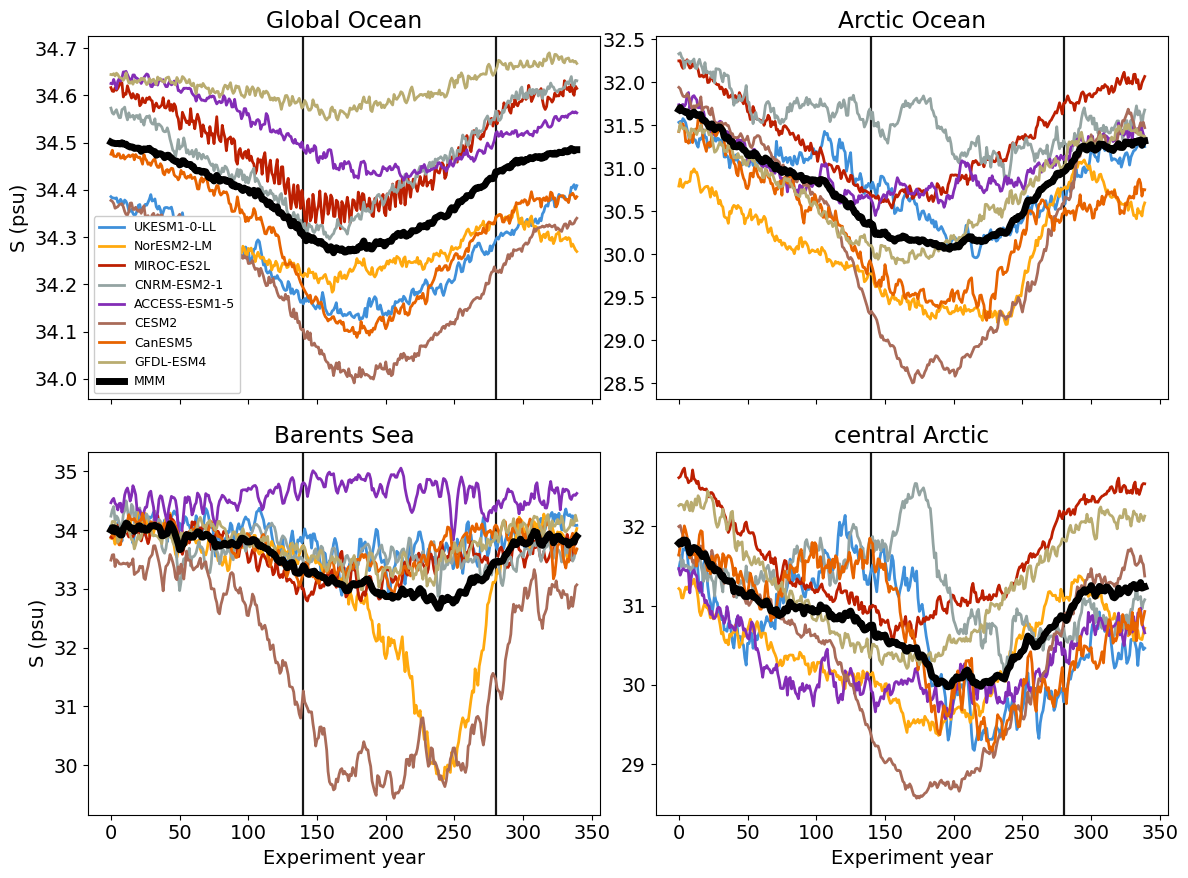

In [18]:
def plot_regional_timeseries(run_params,reg_ts_dict):
    number_of_ts = len(reg_ts_dict.keys())
    fontsize=14
    plt.rcParams['font.size']=fontsize
    fig,ax = plt.subplots(2,int(np.ceil(number_of_ts/2)),figsize=(12,9),sharex=True)
    mmm = dict()
    for regdx,reg in enumerate(reg_ts_dict.keys()):
        cdx = int(np.mod(regdx,2))
        rdx = int(np.floor(regdx/2))
        mmm_dum_list = []
        for key in run_params.keys(): 
            reg_mean_dum = reg_ts_dict[reg][key]
            ax[rdx,cdx].set_title(reg)
            ax[rdx,cdx].plot(reg_mean_dum,color=run_params[key].runcol,label=run_params[key].model,zorder=3,linewidth=2)
            ax[rdx,cdx].axvline(140,color='k',alpha=0.25)
            ax[rdx,cdx].axvline(280,color='k',alpha=0.25)
            mmm_dum_list.append(reg_mean_dum)
        mmm[reg] = xr.concat(mmm_dum_list,dim='keys').mean(dim='keys')
        ax[rdx,cdx].plot(mmm[reg],color='k',zorder=4,linewidth=5,label='MMM')
    ax[0,0].legend(fontsize=fontsize-5,framealpha=1) # bbox_to_anchor=(1.01,0.95),
    ax[-1,0].set_xlabel('Experiment year')
    ax[-1,1].set_xlabel('Experiment year')
    ax[0,0].set_ylabel('S (psu)')#'mol m$^{-3}$')
    ax[1,0].set_ylabel('S (psu)')#'mol m$^{-3}$')
    plt.tight_layout()
    plt.show()
    return fig,ax
    
fig,ax = plot_regional_timeseries(run_params,regional_time_series_2)
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_time_4regions_{variable_to_analyze}.png',dpi=300,transparent=True)


## Plot the central Arctic time series alone, against time, but fancy

Plot the regional time series, but in fancy....


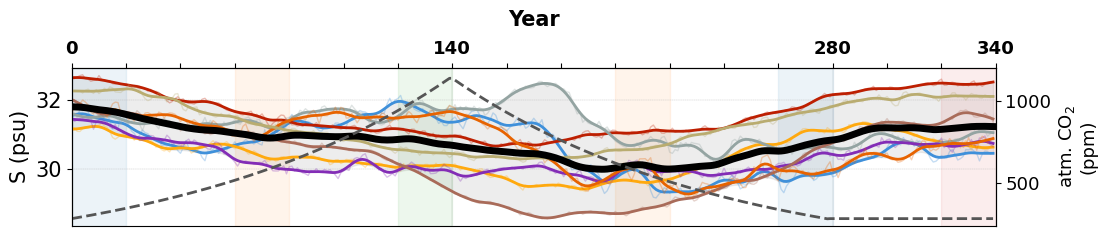

In [19]:
print('Plot the regional time series, but in fancy....')
fig, ax, ax2 = Plotter._plot_regional_time_series_fancy(run_params,regional_time_series_2,'central Arctic',variable_to_analyze,'S (psu)',include_atmCO2=True)
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_co2_1region_fancy_{variable_to_analyze}.png',dpi=300,transparent=True)

## Now plot the time slice averages, including for the piControl

Setting parameters...
Opening the variable's model dataset...
Compute time slice averages.....
Now plot the time slice....


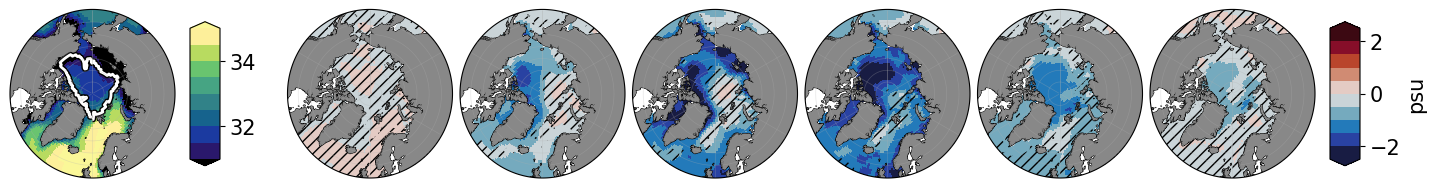

In [20]:
print('Setting parameters...')
pic_params = Params.standard_set_piControl() #Params.test_set_1pctCO2cdr()  #

print("Opening the variable's model dataset...")
pic_paths = ModelDataGetter._identify_path_strings(pic_params,variable_to_analyze,depth_to_analyze)
pic_data   = ModelDataGetter._open_datasets(pic_paths)

print('Compute time slice averages.....')
time_slices='standard'
time_slice_type='anom_to_preindustrial_initial'
time_slice_averages_mmm, time_slice_averages_agreement = MMFuncs._calc_time_slice_averages(ds_data,pic_data,temporal_resolution,time_slices=time_slices,time_slice_type=time_slice_type)

print('Now plot the time slice....')
# set colormaps and units
cmap = plt.get_cmap('cmo.haline',8);cmap.set_over('#faf798');cmap.set_under('k')
amap = plt.get_cmap('cmo.balance',10);#amap.set_under('m')
fig, ax = Plotter._plot_time_slice_averages(time_slice_averages_mmm,time_slice_averages_agreement,time_slice_type='anom_to_preindustrial_initial',
                                   vmin=31,vmax=35,
                                   cmap=cmap,
                                   amin=-2.5,amax=2.5,
                                   amap=amap,
                                   unit='psu',
                                   include_region_mask='central Arctic')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_time_slice_averages_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


## Now plot the normalized hysteresis areas, but for each model separately

Plot the hysteresis areas for the individual models.....


/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


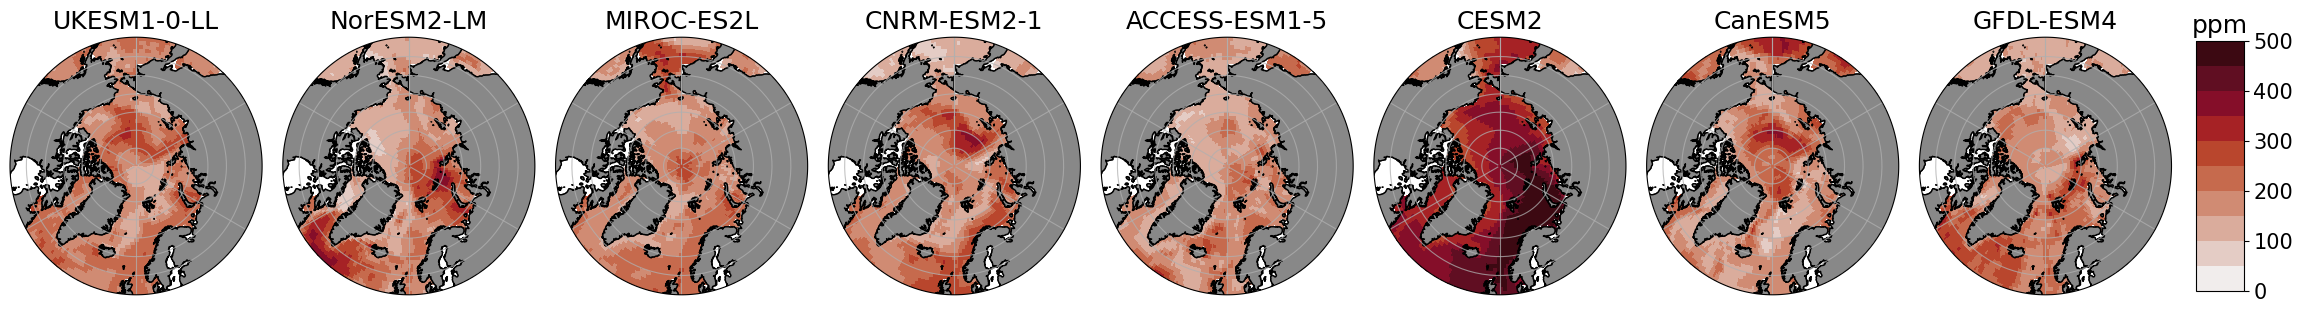

/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


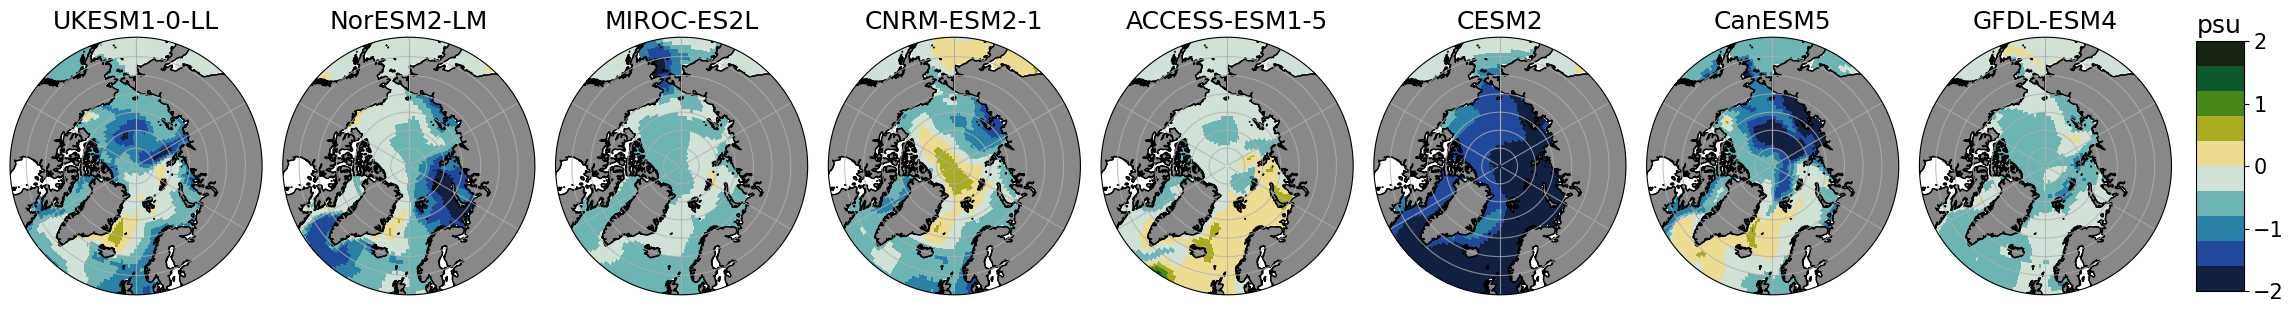

In [21]:
print('Plot the hysteresis areas for the individual models.....')
fig, ax = Plotter._plot_variable_for_individual_models(run_params,hyst_dict,da_name='normalized_hysteresis_area',vmin=0,vmax=500,cmap=plt.get_cmap('cmo.amp',10),unit='ppm')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)
    
fig, ax = Plotter._plot_variable_for_individual_models(run_params,hyst_dict,da_name='signed_hysteresis_area',vmin=-2,vmax=2,cmap=plt.get_cmap('cmo.delta',10),unit='psu')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)